> **Note:** The cell below generates synthetic demo ECG data into `./data/`.
> It requires `neurokit2`, which is not installed by default:
> ```
> pip install neurokit2
> ```


In [1]:
# %pip install neurokit2
# Run this once to generate the demo data (requires neurokit2)
# pip install neurokit2
from atriakit import create_demo_data
create_demo_data(output_dir="./data")


[DEMO001] Simulating 12-lead ECG at 60 bpm …
  Saved data/DEMO001.dcm
  Detected 9 P-waves
[DEMO002] Simulating 12-lead ECG at 75 bpm …
  Saved data/DEMO002.dcm
  Detected 12 P-waves
[DEMO003] Simulating 12-lead ECG at 90 bpm …
  Saved data/DEMO003.dcm
  Detected 14 P-waves

Saved data/demo_annotations.csv (420 rows across 3 patients)


PosixPath('data')

In [2]:
import matplotlib.pyplot as plt
import os
from pathlib import Path
import yaml
from atriakit import Pipeline, ECGLoader, FeatureCalculators, AnnotationsLoader

CONFIG_TEMPLATE_PATH = Path("./pipeline_config.yaml")
CONFIG_PATH = Path("./demo_pipeline_config.yaml")
config = yaml.safe_load(CONFIG_TEMPLATE_PATH.read_text(encoding="utf-8"))
config["annotations_dir"] = "./data"
config.pop("annotations_csv", None)

# Pipeline

### With YAML

In [3]:
pipeline, annotations = Pipeline.from_yaml(CONFIG_PATH)
result = pipeline.run(annotations)

# Alternative to the top if you don't want to get the pipeline and annotations objects
# result = Pipeline.run_from_yaml(CONFIG_PATH)

FileNotFoundError: [Errno 2] No such file or directory: '/home/nikolay/ETH/AtriaKit/examples/demo_pipeline_config.yaml'

### With default config

In [ ]:
from atriakit import AnnotationsLoader
p = Pipeline(ecg_base_path="./data")
annotations = AnnotationsLoader().load(
    "./data/demo_annotations.csv"
)

result = p.run(annotations)

100%|██████████| 3/3 [00:00<00:00,  3.92it/s]


In [ ]:
# To calculate metrics FeatureCalculators expects an Annotations object and the corresponding ECG wrapped in ECGData.
from atriakit import ECGLoader 
fc = FeatureCalculators()

# Let's analyse the annotations for the first ECG/IMA file.
# FeatureCalculators works on 1 file at a time.
ecg_file_path = annotations.iloc[0]["file_path"]
full_file_path = os.path.join("./data", ecg_file_path)

ecg_data = ECGLoader().load(full_file_path)
_, file_annotations = next(iter(annotations.groupby("file_path")))

area = fc.area(file_annotations, ecg_data)
vcg_features = fc.vcg_eigenfeatures(file_annotations, ecg_data)
max_amplitude = fc.max_amplitude(file_annotations, ecg_data)

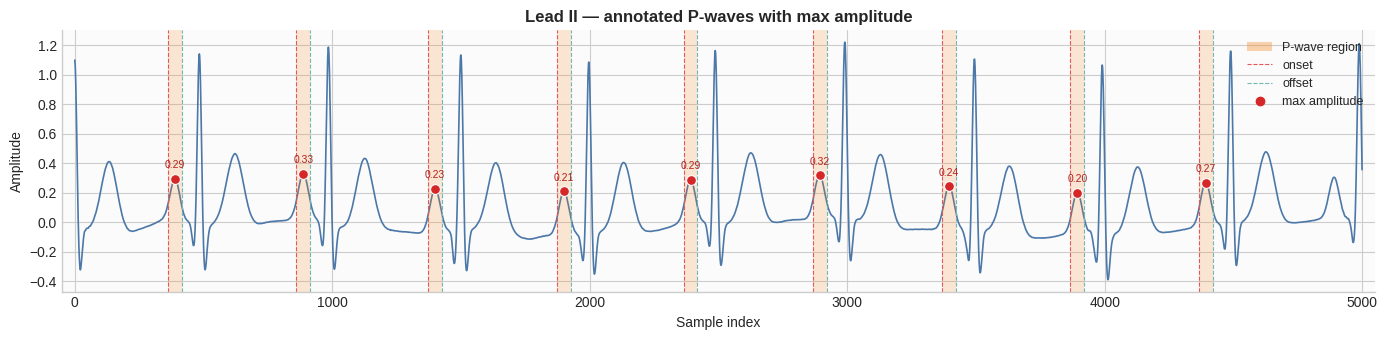

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Full Lead II with max amplitude marked on every P-wave
lead = "II"
signal = ecg_data.get_lead_signal(lead, preprocessor=fc.signal_preprocessor)
df = file_annotations.get_df()
lead_anns = df[df["lead"] == lead].sort_values("onset")

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.set_facecolor('#fbfbfc')
ax.plot(signal, color='#4c78a8', linewidth=1.2, zorder=1)

for _, row in lead_anns.iterrows():
    onset, offset = int(row["onset"]), int(row["offset"])
    segment = signal[onset:offset + 1]
    peak_idx = onset + segment.argmax()
    peak_val = signal[peak_idx]
    ax.axvspan(onset, offset, alpha=0.18, color='#f58518', lw=0)
    ax.axvline(onset,  color="#e45756", lw=0.8, ls="--")
    ax.axvline(offset, color="#72b7b2", lw=0.8, ls="--")
    ax.scatter(peak_idx, peak_val, s=50, color='#d62728', zorder=3, edgecolor='white', linewidth=0.8)
    ax.annotate(f'{peak_val:.2f}', xy=(peak_idx, peak_val),
               xytext=(0, 6), textcoords='offset points',
               fontsize=7.5, color='#b22222', ha='center', va='bottom')

handles = [
    Patch(facecolor='#f58518', alpha=0.35, label='P-wave region'),
    Line2D([0],[0], color='#e45756', lw=0.8, ls='--', label='onset'),
    Line2D([0],[0], color='#72b7b2', lw=0.8, ls='--', label='offset'),
    Line2D([0],[0], color='#d62728', marker='o', lw=0, ms=6, label='max amplitude'),
]
ax.legend(handles=handles, frameon=False, loc='upper right', fontsize=9)
ax.set_title(f'Lead {lead} — annotated P-waves with max amplitude', fontsize=12, weight='bold')
ax.set_xlabel('Sample index')
ax.set_ylabel('Amplitude')
ax.spines[['top', 'right']].set_visible(False)
ax.margins(x=0.01)
fig.tight_layout()
plt.show()